In [1]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

## Forma dei dati (Bode modulo)

Le quantità che uso per il fit sono:

- Variabile indipendente:
$$
x = \log_{10} (f)
$$

- Errore su x (trascurato):
$$
\sigma_x = 0
$$

- Variabile dipendente (in dB):
$$
y = 20 \log_{10}\!\left(\frac{V_{out}}{V_{in}}\right)
$$

- Errore su y:
$$
\sigma_y = 20 \frac{\sigma_A}{A \ln 10}
\quad \text{con} \quad
A = \frac{V_{out}}{V_{in}}
$$

---

## Modello fittato

Per un filtro RC passa-basso:

$$
y(f) = -10 \log_{10}\!\left(1 + \left(\frac{f}{f_c}\right)^2 \right)
$$

dove:
- $( f )$ = frequenza
- $( f_c )$ = frequenza di taglio (parametro del fit)

---

## Parametro fisico ricavato

Dalla frequenza di taglio:

$$
RC = \frac{1}{2\pi f_c}
$$

In [2]:
def modello(par, x):
    return -10 * np.log10(1 + ( 10**(x + par[1]) / par[0])**2) + par[2]

param_labels = ["f_c", "x_off", "y_off"]

beta0 = [5.20005 * 10**3, 0, 0]

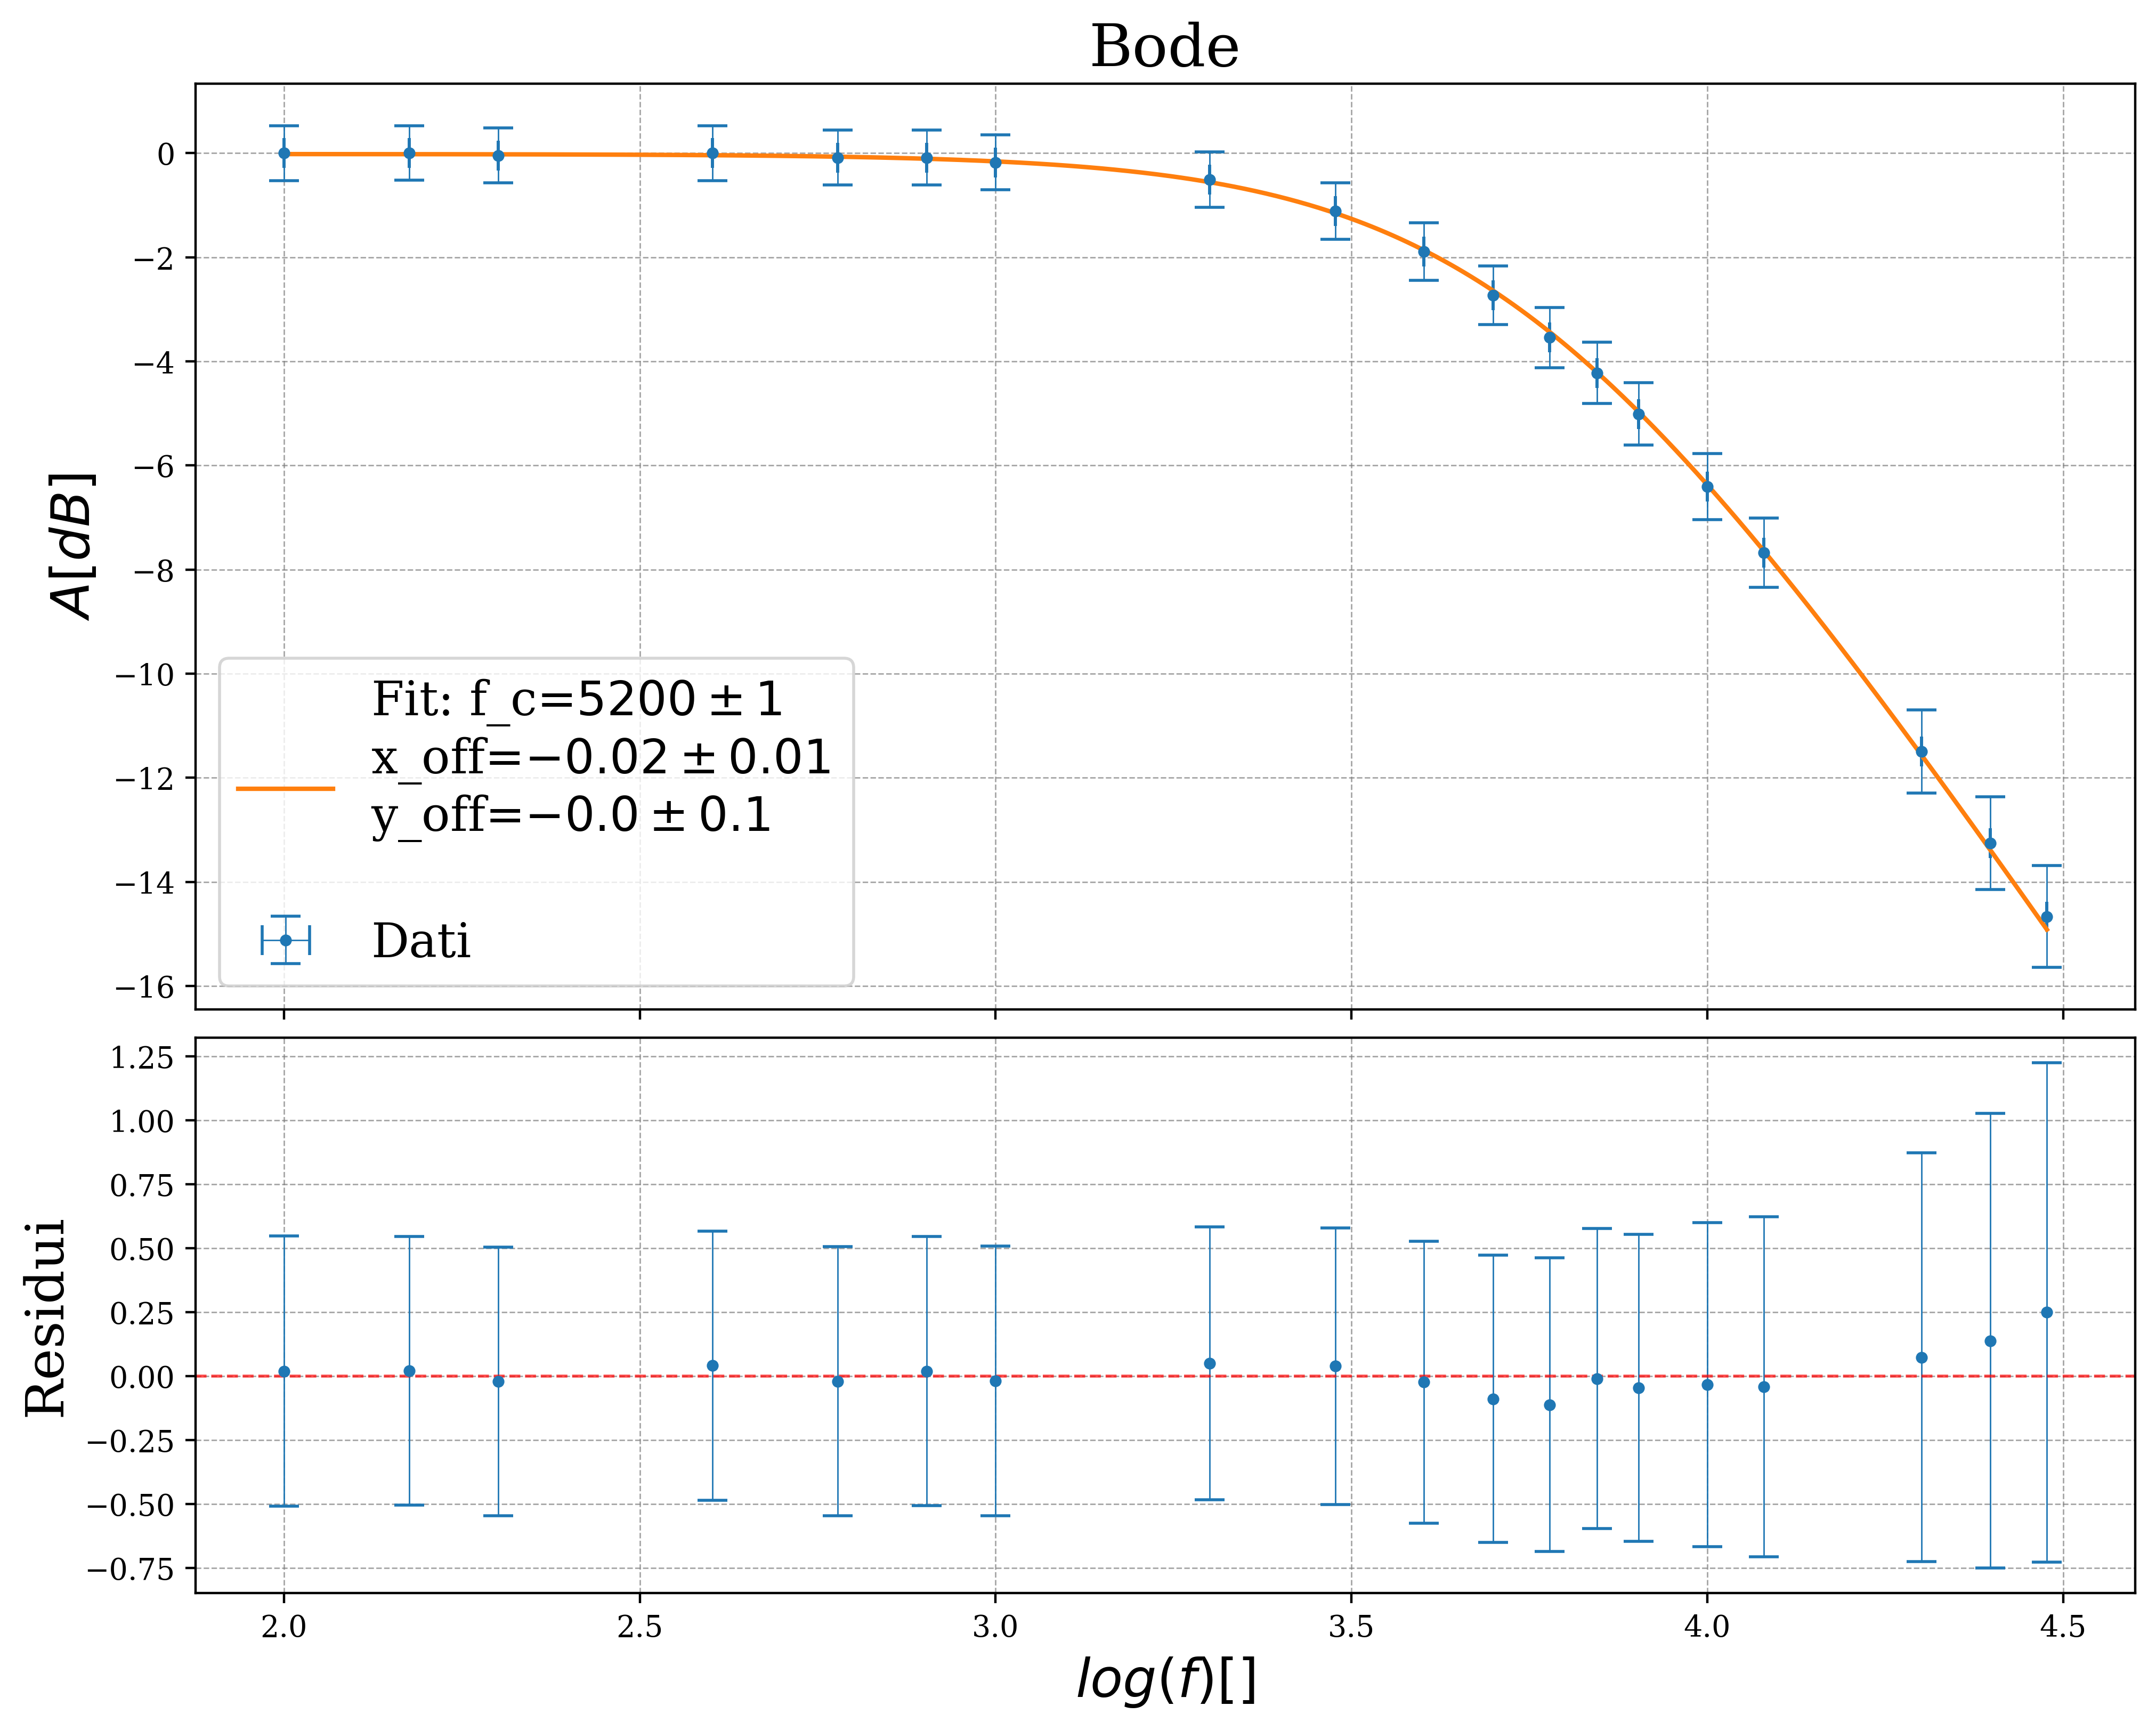

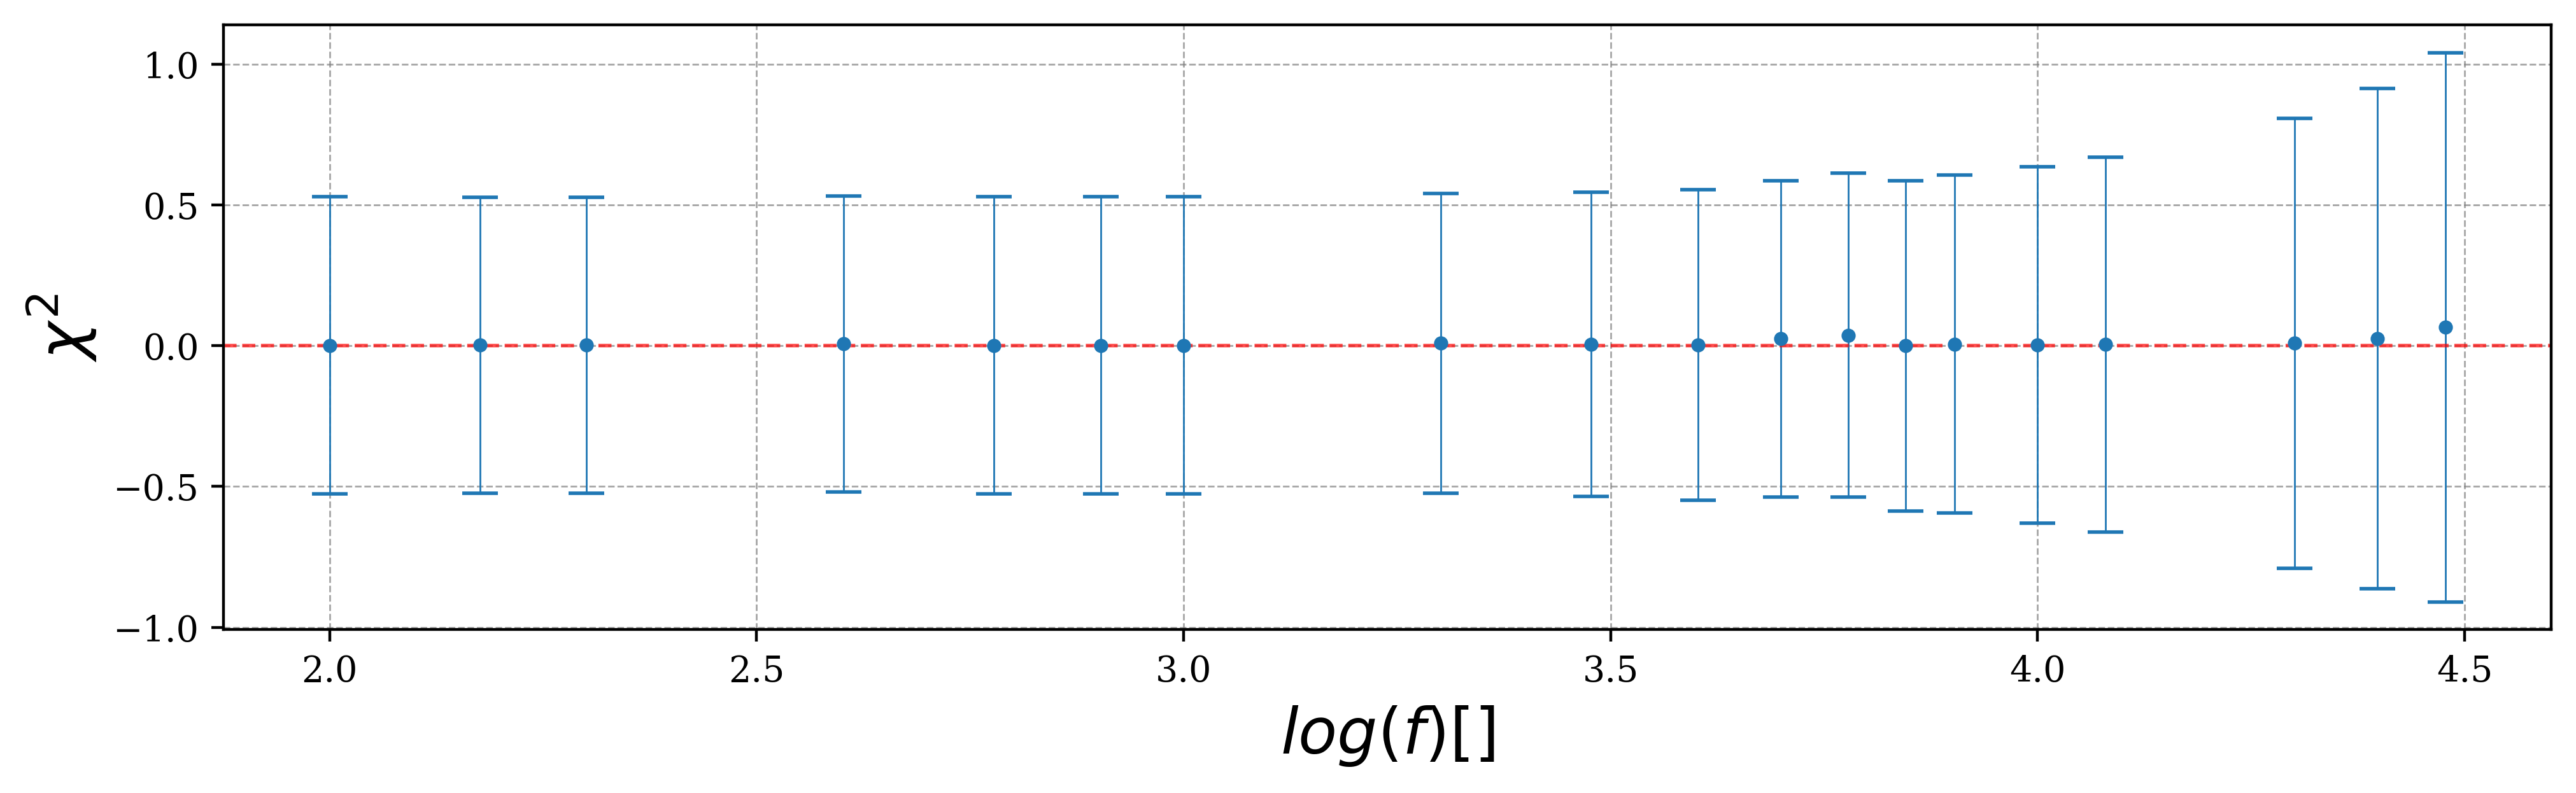

In [3]:
risultati = analizza("bode.json", modello, param_labels, beta0)

In [4]:
print(risultati)

Parametri regressione :
5200.050001574502 ± 0.9999999969949522
-0.02336539617589446 ± 0.014446627473420515
-0.018263287126214264 ± 0.128234422273297

Somma residui :
0.2434
Somma chi quadri e chi ridotto :
0.2041
0.0128



In [5]:
risultati_dict = let.ris_fit_to_dict(risultati)
gf.display_dizionario(risultati_dict)
let.esporta_pickle(risultati_dict, filename = f"bode.pkl")

parametri,[ 5.20005000e+03 -2.33653962e-02 -1.82632871e-02]
s_parametri,[1. 0.01444663 0.12823442]
res,0.2434448334592571
chi,0.20410777104721153
chi_ridotto,0.01275673569045072
